# Hafta 4 — İnterpolasyon ve Yaklaşıklama: Lagrange, Newton, Spline'lar ve En Küçük Kareler

> **Sıfırdan Sayısal Yöntemler** · Saf NumPy + Matplotlib

Veri noktaları verildiğinde, ya bunlardan geçen bir fonksiyon isteriz (**interpolasyon**) ya da aşırı uydurmadan eğilimi yakalayan bir fonksiyon (**yaklaşıklama**). Bu hafta inşa ediyoruz:

1. Lagrange ve Newton bölünmüş-fark biçimleriyle **polinom interpolasyonu**.
2. **Runge olgusu** — eşit aralıklı düğümlerde yüksek dereceli interpolasyonun neden felaket olduğu ve **Chebyshev düğümlerinin** bunu nasıl düzelttiği.
3. **Kübik spline'lar** — sürekli eğriliğe sahip parçalı kübikler, pratik iş gücü.
4. Normal denklemlerle **en küçük kareler** polinom uydurma ve neden bunu gerçekte böyle hesaplamamanız gerektiği.

Derin ders: interpolasyon ve yaklaşıklama, yalnızca dereceyle değil, *düğümlerin yerleşimi* ve *tabanın koşullanması* tarafından yönetilir.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Lagrange interpolasyonu

$n+1$ nokta $(x_i, y_i)$'den geçen, derecesi $\le n$ olan tek polinom **Lagrange tabanında** şöyle yazılır:

$$ p(x) = \sum_{i=0}^{n} y_i\, \ell_i(x), \qquad \ell_i(x) = \prod_{j\neq i} \frac{x - x_j}{x_i - x_j}. $$

Her taban fonksiyonu $\ell_i$, $x_i$'de $1$ ve diğer her düğümde $0$'dır — yani interpolasyon özelliği yerleşiktir. Teori için zariftir ama değerlendirme başına $\mathcal{O}(n^2)$ maliyetlidir ve güncellemesi zahmetlidir.


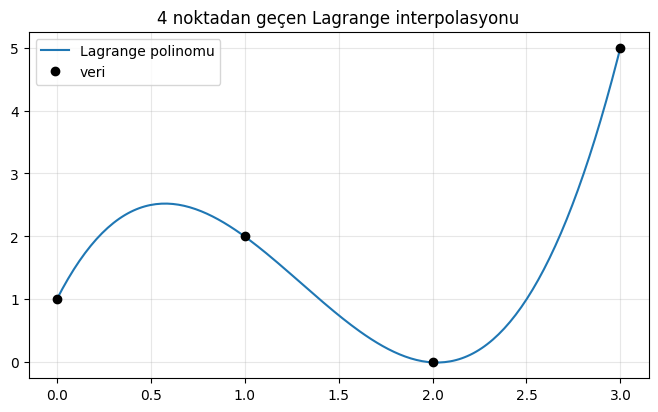

In [2]:
def lagrange_interp(xdugum, ydugum, xq):
    xq = np.atleast_1d(xq).astype(float)
    n = len(xdugum)
    sonuc = np.zeros_like(xq)
    for i in range(n):
        Li = np.ones_like(xq)
        for j in range(n):
            if j != i:
                Li *= (xq - xdugum[j]) / (xdugum[i] - xdugum[j])
        sonuc += ydugum[i] * Li
    return sonuc

xdugum = np.array([0., 1., 2., 3.])
ydugum = np.array([1., 2., 0., 5.])
xq = np.linspace(0, 3, 200)
yq = lagrange_interp(xdugum, ydugum, xq)

fig, ax = plt.subplots()
ax.plot(xq, yq, label="Lagrange polinomu")
ax.plot(xdugum, ydugum, "ko", label="veri")
ax.set_title("4 noktadan geçen Lagrange interpolasyonu")
ax.legend(); plt.show()


## 2. Newton bölünmüş farkları

Newton biçimi aynı polinomu artımsal olarak kurar; bu da *yeni nokta eklemeyi* ucuzlatır:

$$ p(x) = c_0 + c_1(x-x_0) + c_2(x-x_0)(x-x_1) + \cdots $$

Katsayılar **bölünmüş farklardır** $c_k = f[x_0,\dots,x_k]$ ve şu yinelemeyle hesaplanır:

$$ f[x_i,\dots,x_{i+k}] = \frac{f[x_{i+1},\dots,x_{i+k}] - f[x_i,\dots,x_{i+k-1}]}{x_{i+k}-x_i}. $$

Değerlendirme **Horner benzeri iç içe çarpma** kullanır — verimli ve sayısal olarak dostça.


In [3]:
def bolunmus_farklar(x, y):
    n = len(x)
    kat = y.astype(float).copy()
    for k in range(1, n):
        kat[k:] = (kat[k:] - kat[k-1:-1]) / (x[k:] - x[:-k])
    return kat                              # kat[k] = f[x0,...,xk]

def newton_degerlendir(x, kat, xq):
    xq = np.atleast_1d(xq).astype(float)
    sonuc = np.full_like(xq, kat[-1])
    for k in range(len(kat)-2, -1, -1):
        sonuc = sonuc * (xq - x[k]) + kat[k]
    return sonuc

kat = bolunmus_farklar(xdugum, ydugum)
print("bölünmüş-fark katsayıları:", kat)
yq_newton = newton_degerlendir(xdugum, kat, xq)
print("Lagrange ile aynı mı?", np.allclose(yq_newton, yq))


bölünmüş-fark katsayıları: [ 1.          1.         -1.5         1.66666667]
Lagrange ile aynı mı? True


Her iki biçim de *aynı* polinomu üretir (o tektir) — yalnızca temsil ve değerlendirme şekilleri farklıdır.

## 3. Runge olgusu

Daha fazla düğüm = daha iyi uydurma diye düşünmek caziptir. **Eşit aralıklı** düğümler ve yüksek derece için tam tersi olur: interpolant uçlarda çılgınca salınır. Ders kitabı örneği Runge fonksiyonudur $f(x) = \frac{1}{1+25x^2}$, $[-1,1]$ üzerinde.


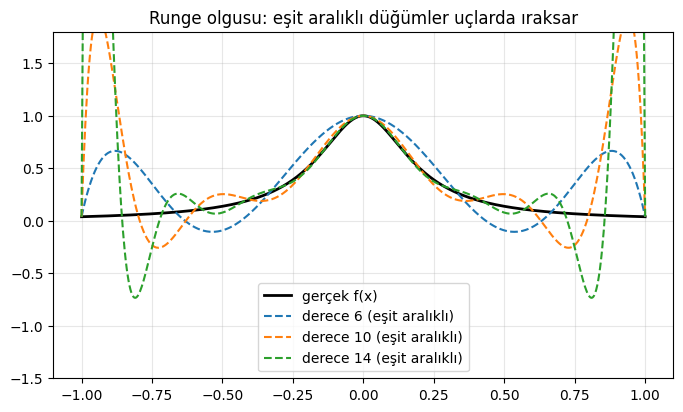

In [4]:
runge = lambda x: 1.0 / (1 + 25*x**2)
xince = np.linspace(-1, 1, 600)

fig, ax = plt.subplots()
ax.plot(xince, runge(xince), "k", lw=2, label="gerçek f(x)")
for n in [6, 10, 14]:
    xe = np.linspace(-1, 1, n+1)              # EŞİT ARALIKLI düğümler
    ce = bolunmus_farklar(xe, runge(xe))
    ax.plot(xince, newton_degerlendir(xe, ce, xince), "--", label=f"derece {n} (eşit aralıklı)")
ax.set_ylim(-1.5, 1.8)
ax.set_title("Runge olgusu: eşit aralıklı düğümler uçlarda ıraksar")
ax.legend(); plt.show()


### Çözüm: Chebyshev düğümleri

Düğümleri uçlara doğru kümeleyin; **Chebyshev noktalarını** kullanın:

$$ x_k = \cos\!\left(\frac{k\pi}{n}\right), \quad k=0,\dots,n. $$

Bu kümeleme hata büyümesini evcilleştirir ve interpolant yüksek derecede bile güzelce yakınsar.


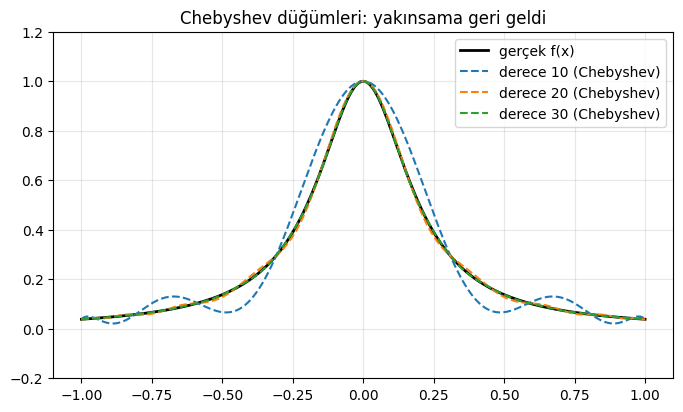

In [5]:
def chebyshev_dugumleri(n):
    return np.cos(np.pi * np.arange(n+1) / n)

fig, ax = plt.subplots()
ax.plot(xince, runge(xince), "k", lw=2, label="gerçek f(x)")
for n in [10, 20, 30]:
    xc = chebyshev_dugumleri(n)
    cc = bolunmus_farklar(xc, runge(xc))
    ax.plot(xince, newton_degerlendir(xc, cc, xince), "--", label=f"derece {n} (Chebyshev)")
ax.set_ylim(-0.2, 1.2)
ax.set_title("Chebyshev düğümleri: yakınsama geri geldi")
ax.legend(); plt.show()


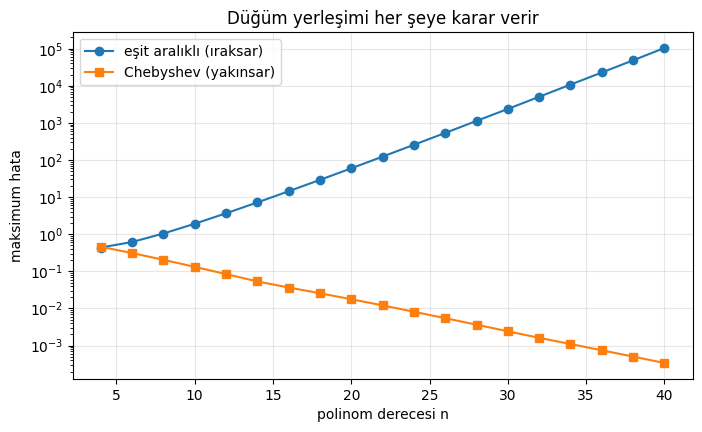

In [6]:
# Nicele: iki düğüm kümesi için dereceye karşı maksimum hata.
dereceler = range(4, 41, 2)
hata_esit, hata_cheb = [], []
for n in dereceler:
    xe = np.linspace(-1, 1, n+1)
    hata_esit.append(np.max(np.abs(newton_degerlendir(xe, bolunmus_farklar(xe, runge(xe)), xince) - runge(xince))))
    xc = chebyshev_dugumleri(n)
    hata_cheb.append(np.max(np.abs(newton_degerlendir(xc, bolunmus_farklar(xc, runge(xc)), xince) - runge(xince))))

fig, ax = plt.subplots()
ax.semilogy(list(dereceler), hata_esit, "o-", label="eşit aralıklı (ıraksar)")
ax.semilogy(list(dereceler), hata_cheb, "s-", label="Chebyshev (yakınsar)")
ax.set_xlabel("polinom derecesi n"); ax.set_ylabel("maksimum hata")
ax.set_title("Düğüm yerleşimi her şeye karar verir"); ax.legend(); plt.show()


## 4. Kübik spline'lar

Tek bir yüksek dereceli polinom yerine, **her aralıkta ayrı bir kübik** uydurun ve bunları fonksiyon, birinci türev ve ikinci türev sürekli olacak şekilde birbirine dikin. Sonuç pürüzsüz, yerel ve Runge tarzı salınıma karşı bağışıktır. **Doğal** spline ek olarak iki uçta ikinci türevi sıfıra ayarlar.

Bunu kurmak, ikinci türevler $M_i$ için üç köşegenli bir sistem çözmeye indirgenir — geçen haftanın lineer çözücülerinin mükemmel bir uygulaması.


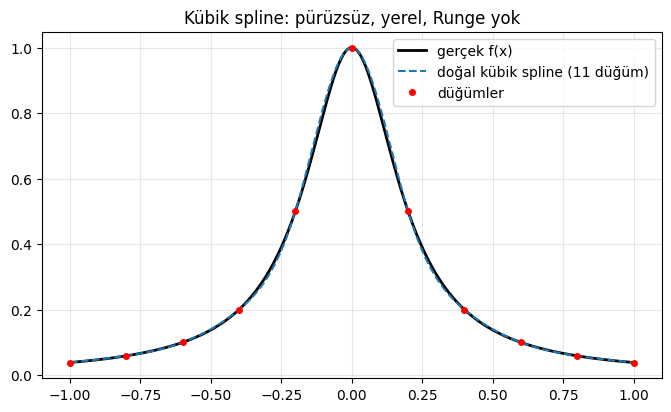

In [7]:
def dogal_kubik_spline(x, y):
    n = len(x) - 1
    h = np.diff(x)
    # İkinci türevler M için üç köşegenli sistem (doğal: M0 = Mn = 0).
    A = np.zeros((n+1, n+1)); rhs = np.zeros(n+1)
    A[0, 0] = 1.0; A[n, n] = 1.0
    for i in range(1, n):
        A[i, i-1] = h[i-1]
        A[i, i]   = 2*(h[i-1] + h[i])
        A[i, i+1] = h[i]
        rhs[i] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])
    M = np.linalg.solve(A, rhs)

    def degerlendir(xq):
        xq = np.atleast_1d(xq).astype(float)
        out = np.zeros_like(xq)
        idx = np.clip(np.searchsorted(x, xq) - 1, 0, n-1)
        for k, (xi, i) in enumerate(zip(xq, idx)):
            dx = xi - x[i]; hi = h[i]
            a = (x[i+1]-xi)/hi; b = dx/hi
            out[k] = (a*y[i] + b*y[i+1]
                      + ((a**3 - a)*M[i] + (b**3 - b)*M[i+1]) * hi**2 / 6)
        return out
    return degerlendir

xs = np.linspace(-1, 1, 11)
spline = dogal_kubik_spline(xs, runge(xs))
fig, ax = plt.subplots()
ax.plot(xince, runge(xince), "k", lw=2, label="gerçek f(x)")
ax.plot(xince, spline(xince), "--", label="doğal kübik spline (11 düğüm)")
ax.plot(xs, runge(xs), "ro", ms=4, label="düğümler")
ax.set_title("Kübik spline: pürüzsüz, yerel, Runge yok"); ax.legend(); plt.show()


## 5. En küçük kareler yaklaşıklaması

Veri gürültülüyse ya da *çok sayıda* nokta arasından *düşük dereceli* bir eğilim istiyorsak, interpolasyon koşulunu bırakıp kare kalıntıyı minimize ederiz:

$$ \min_{c} \|V c - y\|_2^2, $$

burada $V$ **Vandermonde** tasarım matrisidir. Normal denklemler $V^\top V c = V^\top y$ klasik çözümü verir — ama $V^\top V$ koşul sayısını kareler, bu yüzden düşük derecenin ötesinde her şey için QR çarpanlamasi (6. hafta konusu) kullanılmalıdır.


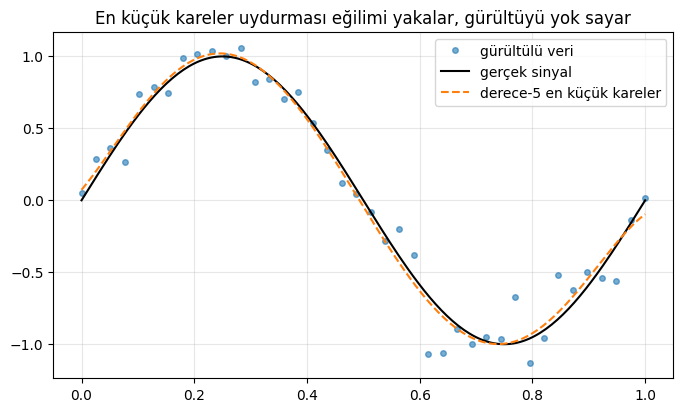

kappa(V)      : 3482.968340390914
kappa(V^T V)  : 12131068.460278971   <- karelendi! yüksek derece için QR kullanın


In [8]:
def polyfit_normal(x, y, derece):
    V = np.vander(x, derece+1, increasing=True)   # tasarım matrisi
    # Normal denklemleri çöz (gösterim amaçlı; kararlılık için QR tercih edilir).
    return np.linalg.solve(V.T @ V, V.T @ y)

rng = np.random.default_rng(1)
xveri = np.linspace(0, 1, 40)
ygercek = np.sin(2*np.pi*xveri)
ygurultu = ygercek + 0.15*rng.standard_normal(xveri.size)

c = polyfit_normal(xveri, ygurultu, 5)
xdeg = np.linspace(0, 1, 200)
ydeg = np.vander(xdeg, 6, increasing=True) @ c

fig, ax = plt.subplots()
ax.plot(xveri, ygurultu, "o", ms=4, alpha=0.6, label="gürültülü veri")
ax.plot(xdeg, np.sin(2*np.pi*xdeg), "k", label="gerçek sinyal")
ax.plot(xdeg, ydeg, "--", label="derece-5 en küçük kareler")
ax.set_title("En küçük kareler uydurması eğilimi yakalar, gürültüyü yok sayar"); ax.legend(); plt.show()

# Koşul sayısı uyarısı:
V = np.vander(xveri, 6, increasing=True)
print("kappa(V)      :", np.linalg.cond(V))
print("kappa(V^T V)  :", np.linalg.cond(V.T @ V), "  <- karelendi! yüksek derece için QR kullanın")


## Özet

- Lagrange ve Newton biçimleri **aynı tek** interpolasyon polinomunu verir; Newton biçimi ucuza güncellenir.
- **Runge olgusu** yüksek dereceli eşit aralıklı interpolasyonu ıraksatır — **Chebyshev düğümleri** yakınsamayı geri getirir.
- **Kübik spline'lar** pratik varsayılandır: pürüzsüz, yerel, salınımsız.
- **En küçük kareler** tam uydurmayı gürültü sağlamlığıyla takas eder; normal denklemler $\kappa$'yı kareler, bu yüzden kararlılık için QR tercih edin.

---

## Alıştırmalar

**1. (Barisentrik biçim.)** Ağırlıkları önceden hesaplayıp $\mathcal{O}(n)$'de değerlendiren *barisentrik* Lagrange formülünü kodlayın. $\mathcal{O}(n^2)$ sürümünüzle eşleştiğini ve yüksek derecede çok daha kararlı olduğunu doğrulayın.

**2. (Lebesgue sabiti.)** Eşit aralıklı vs. Chebyshev düğümleri için Lebesgue sabitini $\Lambda_n = \max_x \sum_i |\ell_i(x)|$ sayısal kestirip büyümesini Runge olgusuna bağlayın.

**3. (Kenetlenmiş spline.)** Spline'ınızı *kenetlenmiş* (clamped) sınır koşuluna (uç eğimleri belirtilmiş) genişletin. Uçlardaki davranışını doğal spline ile karşılaştırın.

**4. (Hermite interpolasyonu.)** İki noktada hem değerleri hem türevleri eşleyen bir kübik Hermite interpolant kurun. $\sin x$'i interpole etmek için kullanıp hatayı ölçün.

**5. (Aşırı uydurma eğrisi.)** Gürültülü sinüs verisi için eğitim hatasını ve ayrılmış bir test hatasını polinom derecesinin (1'den 15'e) fonksiyonu olarak çizin. Aşırı uydurmanın başladığı dereceyi belirleyip yukarıdaki koşullanma uyarısına bağlayın.
